In [1]:
import os
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.data import Subset
import torch.optim as optim
import torch.nn.functional as F

In [2]:
torch.cuda.is_available()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
torch.cuda.device_count() # returns 1 in my case


if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

cuda:0
GPU: NVIDIA RTX A6000 is available.


In [3]:
import os
import random
from pathlib import Path
from shutil import copy2

# === Setup ===
INPUT_DIR = "/home/HardDisk/Satang/thesis_proj/New_60/10/raw_data_normalized_5"
OUTPUT_BASE = "/home/HardDisk/Satang/thesis_proj/New_60/10/split_tws_5"  # You can change this if needed
SPLIT_RATIOS = (0.7, 0.15, 0.15)  # Train, Val, Test
SEED = 42

# === Prepare output folders ===
splits = ['train', 'val', 'test']
for split in splits:
    for cls in os.listdir(INPUT_DIR):
        os.makedirs(os.path.join(OUTPUT_BASE, split, cls), exist_ok=True)

# === Perform the split ===
random.seed(SEED)

for cls in sorted(os.listdir(INPUT_DIR)):
    class_path = os.path.join(INPUT_DIR, cls)
    if not os.path.isdir(class_path):
        continue

    files = sorted([f for f in os.listdir(class_path) if f.endswith(".csv")])
    random.shuffle(files)

    n_total = len(files)
    n_train = int(n_total * SPLIT_RATIOS[0])
    n_val = int(n_total * SPLIT_RATIOS[1])
    n_test = n_total - n_train - n_val

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    for f in train_files:
        src = os.path.join(class_path, f)
        dst = os.path.join(OUTPUT_BASE, "train", cls, f)
        copy2(src, dst)

    for f in val_files:
        src = os.path.join(class_path, f)
        dst = os.path.join(OUTPUT_BASE, "val", cls, f)
        copy2(src, dst)

    for f in test_files:
        src = os.path.join(class_path, f)
        dst = os.path.join(OUTPUT_BASE, "test", cls, f)
        copy2(src, dst)

print("✅ Done! Files have been split and copied to:", OUTPUT_BASE)


✅ Done! Files have been split and copied to: /home/HardDisk/Satang/thesis_proj/New_60/10/split_tws_5


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd

# Config
DATA_ROOT = Path("/home/HardDisk/Satang/thesis_proj/New_60/10/split_tws_5")  # Folder structure: split/train/class/*.csv

INNER_STRIDE = 1
NUM_FEATURES = 5

def extract_x_vectors(csv_path, t_window, inner_stride):
    df = pd.read_csv(csv_path, header=None).values  # shape: (time, 8)
    x_vectors = []

    for i in range(0, len(df) - t_window + 1, inner_stride):
        window = df[i:i + t_window, :]  # shape: (t_window, 8)
        vector = np.mean(window, axis=0)
        x_vectors.append(vector)

    return np.array(x_vectors)  # shape: (N_x, 8)

def extract_time_aware_samples(x_vectors, t_d, t_window):
    sample_len = t_d - t_window + 1
    outer_stride = max(1, int(0.25 * sample_len))  # 75% overlap → 25% stride

    samples = []
    for i in range(0, len(x_vectors) - sample_len + 1, outer_stride):
        chunk = x_vectors[i:i + sample_len]
        samples.append(chunk)

    return np.stack(samples) if samples else np.empty((0, sample_len, NUM_FEATURES))

def load_dataset_by_split(split, t_window, t_d):
    data = []
    labels = []
    split_path = DATA_ROOT / split

    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue

        for file in sorted(class_dir.glob("*.csv")):
            x_vecs = extract_x_vectors(file, t_window, INNER_STRIDE)
            samples = extract_time_aware_samples(x_vecs, t_d, t_window)

            data.extend(samples)
            labels.extend([class_dir.name] * len(samples))

    return np.array(data), np.array(labels)

# Test configuration (adjust as needed)
T_WINDOW = 10
T_D = 60
sample_len = T_D - T_WINDOW + 1

X_train, y_train = load_dataset_by_split("train", T_WINDOW, T_D)
X_train.shape, y_train.shape, sample_len
# Example call: load training data
X_train, y_train =load_dataset_by_split("train", T_WINDOW, T_D)
X_val, y_val = load_dataset_by_split("val", T_WINDOW,T_D)
X_test, y_test = load_dataset_by_split("test", T_WINDOW,T_D)


X_train.shape, y_train.shape



((3037, 51, 5), (3037,))

In [5]:
def split_csv_into_chunks(input_root, output_root, t_window, t_d, num_features=8):
    input_root = Path(input_root)
    output_root = Path(output_root)
    sample_counter = {}

    chunk_len = t_d - t_window + 1
    stride = max(1, int(0.25 * chunk_len))  # 75% overlap

    for split in ['train', 'val', 'test']:
        for class_dir in (input_root / split).iterdir():
            if not class_dir.is_dir():
                continue

            class_name = class_dir.name
            out_class_dir = output_root / split / class_name
            out_class_dir.mkdir(parents=True, exist_ok=True)

            for file in sorted(class_dir.glob("*.csv")):
                df = pd.read_csv(file, header=None).values
                if df.shape[1] != num_features:
                    continue

                sample_counter.setdefault(class_name, 0)
                for i in range(0, len(df) - chunk_len + 1, stride):
                    chunk = df[i:i + chunk_len]
                    sample_counter[class_name] += 1

                    out_path = out_class_dir / f"{class_name}_sample_{sample_counter[class_name]:04d}.csv"
                    pd.DataFrame(chunk).to_csv(out_path, index=False, header=False)

    print(f"✅ Done: All files split into ({chunk_len}, {num_features}) samples with stride={stride}.")

split_csv_into_chunks(
    input_root="/home/HardDisk/Satang/thesis_proj/New_60/10/split_tws_5",
    output_root="/home/HardDisk/Satang/thesis_proj/New_60/10/split_tws_5/X_csv_split_51",
    t_window=10,
    t_d=60,
    num_features=5
)



✅ Done: All files split into (51, 5) samples with stride=12.


In [6]:
# === CONFIG ===
INPUT_DIR = "/home/HardDisk/Satang/thesis_proj/New_60/10/split_tws_5/X_csv_split_51"
CHUNK_SIZE = 51
NUM_FEATURES = 5
NUM_EPOCHS = 50
BATCH_SIZE = 32
K_FOLDS = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# === HELPERS ===
def collate_fn(batch):
    streams, labels = zip(*batch)
    streams = list(zip(*streams))
    streams = [torch.stack(s) for s in streams]
    labels = torch.tensor(labels)
    return streams, labels

def compute_class_weights(labels, device):
    counter = Counter(labels)
    total = sum(counter.values())
    weights = [np.log(total / (counter[i] + 1)) for i in range(len(counter))]
    return torch.tensor(weights, dtype=torch.float).to(device)

def print_model_info(model):
    print("Model Architecture:")
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

def plot_loss_curve(train_losses, val_losses):
    epochs = range(len(train_losses))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs, val_losses, label='Val Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_accuracy_curve(train_acc, val_acc):
    epochs = range(len(train_acc))
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_acc, label='Train Accuracy', color='green')
    plt.plot(epochs, val_acc, label='Val Accuracy', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [8]:
# === DATASET CLASS ===
class MultiStreamDataset(Dataset):
    def __init__(self, data, labels, label_encoder, augment=False):
        self.data = data
        self.labels = label_encoder.transform(labels)
        self.augment = augment

    def __len__(self):
        return len(self.data)

    def augment_stream(self, stream):
        jitter = np.random.normal(0, 0.01, stream.shape)
        scale = np.random.normal(1.0, 0.05, stream.shape)
        return stream * scale + jitter

    def __getitem__(self, idx):
        sample = self.data[idx]
        # if idx == 0:
        #     print("🔍 Raw feature sample:")
        #     print(sample)
        #     print("Min:", sample.min(), "Max:", sample.max())
        streams = [sample[:, i].reshape(1, -1).astype(np.float32) for i in range(sample.shape[1])]
        if self.augment:
            streams = [self.augment_stream(s.copy()) for s in streams]
        streams = [torch.tensor(s).float() for s in streams]
        label = torch.tensor(self.labels[idx])
        return streams, label


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=dilation, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.downsample(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(self.bn2(self.conv2(out)))
        return F.relu(out + identity)

class MultiStreamCNN(nn.Module):
    def __init__(self, input_length=32, num_classes=12):
        super().__init__()
        self.streams = nn.ModuleList([
            nn.Sequential(
                ResidualBlock(1, 32),
                ResidualBlock(32, 64),
                ResidualBlock(64, 128),
                nn.MaxPool1d(2),
                ResidualBlock(128, 256, dilation=2),
                ResidualBlock(256, 256, dilation=2),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten()
            ) for _ in range(5)
        ])
        self.fc = nn.Sequential(
            nn.LayerNorm(256 * 5),
            nn.Linear(256 * 5, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),   # ✅ extra
            nn.GELU(),             # ✅ extra
            nn.Linear(128, num_classes)
        )
        self.proj = nn.Linear(256 * 5, 128)  # ✅ New: for feature projection

    def forward(self, streams, return_features=False):
        features = [self.streams[i](streams[i]) for i in range(5)]
        x = torch.cat(features, dim=1)
        logits = self.fc(x)
        if return_features:
            feat_proj = self.proj(x)         # ✅ Project [B, 2048] → [B, 128]
            return logits, feat_proj
        return logits  # ✅ Fix: add this

In [10]:

# === COLLATE FUNCTION ===
def collate_fn(batch):
    streams, labels = zip(*batch)
    streams = list(zip(*streams))
    streams = [torch.stack(s) for s in streams]
    labels = torch.tensor(labels)
    return streams, labels

# === LOAD SPLIT FUNCTION ===
def load_split_from_folder(split_dir, expected_shape):
    X, y = [], []
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        for fname in sorted(os.listdir(class_path)):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                chunk = pd.read_csv(fpath, header=None).values
                if chunk.shape == expected_shape:
                    X.append(chunk)
                    y.append(class_name)
    return np.array(X), np.array(y)

In [11]:
# === APPLY SMOTE ===
def apply_smote_on_training(X_chunks, y_labels, chunk_size, num_features):
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_labels)

    smote_encoder = LabelEncoder()
    y_encoded_for_smote = smote_encoder.fit_transform(y_labels)

    X_flat = X_chunks.reshape(X_chunks.shape[0], -1)
    X_resampled, y_resampled = SMOTE().fit_resample(X_flat, y_encoded_for_smote)

    X_res = X_resampled.reshape(-1, chunk_size, num_features)
    y_res_str = smote_encoder.inverse_transform(y_resampled)

    return X_res, y_res_str, label_encoder

# === LOAD DATASETS ===
expected_shape = (CHUNK_SIZE, NUM_FEATURES)

X_train_raw, y_train_raw = load_split_from_folder(os.path.join(INPUT_DIR, "train"), expected_shape)
X_val_raw,   y_val_raw   = load_split_from_folder(os.path.join(INPUT_DIR, "val"), expected_shape)

# === SMOTE ONLY ON TRAIN ===
X_train_balanced, y_train_str, label_encoder = apply_smote_on_training(
    X_train_raw, y_train_raw, CHUNK_SIZE, NUM_FEATURES
)

# === CREATE DATASETS ===
train_dataset = MultiStreamDataset(X_train_balanced, y_train_str, label_encoder, augment=True)
val_dataset   = MultiStreamDataset(X_val_raw, y_val_raw, label_encoder, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


In [12]:

# === CLASS WEIGHTING ===
def compute_class_weights(labels, device):
    from collections import Counter
    total = len(labels)
    counts = Counter(labels)
    weights = [np.log(total / (counts[i] + 1)) for i in range(len(counts))]
    return torch.tensor(weights, dtype=torch.float).to(device)

class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device="cpu")

In [13]:
# # === LOAD ORIGINAL DATA ===
# X_chunks, y_labels = [], []
# for class_name in sorted(os.listdir(INPUT_DIR)):
#     class_path = os.path.join(INPUT_DIR, class_name)
#     if not os.path.isdir(class_path):
#         continue
#     for fname in sorted(os.listdir(class_path)):
#         if fname.endswith(".csv"):
#             fpath = os.path.join(class_path, fname)
#             chunk = pd.read_csv(fpath, header=None).values
#             if chunk.shape == (CHUNK_SIZE, NUM_FEATURES):
#                 X_chunks.append(chunk)
#                 y_labels.append(class_name)

# X_chunks = np.array(X_chunks)
# y_labels = np.array(y_labels)
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y_labels)
# X_flat = X_chunks.reshape(X_chunks.shape[0], -1)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_flat)


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def train_model(model, train_loader, val_loader, device, epochs=50, lr=0.001, class_weights=None,optimizer=None,scheduler=None):
    
    print("🔍 Class Weights Tensor:")
    print(class_weights)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.to(device)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_acc = 0
    best_model_path = "teacher_full.pth"
    printed_shape = False

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        if scheduler:
            scheduler.step()  # ✅ Add this
        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            if not printed_shape:
                print("🔍 Shape of one stream sample:", streams[0].shape)
                printed_shape = True

            outputs = model(streams)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)

                outputs = model(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {total_loss:.4f} - Val Loss: {val_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        # Save best model so far
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)

    # Load the best model before returning
    model.load_state_dict(torch.load(best_model_path))

    return train_accuracies, val_accuracies, train_losses, val_losses


In [15]:
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import confusion_matrix, classification_report
# import matplotlib.pyplot as plt
# import seaborn as sns

# # === CONFIG (shared from earlier) ===
# K_FOLDS = 5
# NUM_EPOCHS = 50
# device = "cpu"  # or "cuda" if GPU is available

# # === PREPROCESS DATA ===
# # Load once and scale
# X_all, y_all = load_split_from_folder(os.path.join(INPUT_DIR, "train"), (CHUNK_SIZE, NUM_FEATURES))
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y_all)
# X_flat = X_all.reshape(X_all.shape[0], -1)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_flat)

# # === K-FOLD TRAINING LOOP ===
# skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
# all_preds_global, all_labels_global = [], []
# all_train_acc, all_val_acc = [], []

# for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_encoded)):
#     print(f"\n--- Fold {fold + 1} / {K_FOLDS} ---")
#     X_train, y_train = X_scaled[train_idx], y_encoded[train_idx]
#     X_val, y_val     = X_scaled[val_idx],   y_encoded[val_idx]

#     # Apply SMOTE
#     X_train_res, y_train_res = SMOTE().fit_resample(X_train, y_train)

#     # Reshape for CNN
#     X_train_final = X_train_res.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
#     y_train_final = label_encoder.inverse_transform(y_train_res)
#     X_val_final = X_val.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
#     y_val_final = label_encoder.inverse_transform(y_val)

#     # Create datasets and loaders
#     train_dataset = MultiStreamDataset(X_train_final, y_train_final, label_encoder, augment=True)
#     val_dataset   = MultiStreamDataset(X_val_final,   y_val_final,   label_encoder, augment=False)

#     train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
#     val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, collate_fn=collate_fn)

#     model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
#     print_model_info(model)

#     class_weights_tensor = compute_class_weights(train_dataset.labels, device)
#     train_accs, val_accs, train_losses, val_losses = train_model(
#         model, train_loader, val_loader, device, epochs=NUM_EPOCHS, class_weights=class_weights_tensor
#     )

#     all_train_acc.append(train_accs[-1])
#     all_val_acc.append(val_accs[-1])
#     plot_loss_curve(train_losses, val_losses)
#     plot_accuracy_curve(train_accs, val_accs)

#     # Validation prediction for confusion matrix
#     model.eval()
#     with torch.no_grad():
#         for streams, labels in val_loader:
#             streams = [s.to(device) for s in streams]
#             labels = labels.to(device)
#             outputs = model(streams)
#             preds = torch.argmax(outputs, dim=1)
#             all_preds_global.extend(preds.cpu().numpy())
#             all_labels_global.extend(labels.cpu().numpy())

# # === FINAL REPORT ===
# cm = confusion_matrix(all_labels_global, all_preds_global)
# plt.figure(figsize=(10, 8))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
# plt.title('Combined Confusion Matrix (All Folds)')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.tight_layout()
# plt.show()

# print("\nFinal Combined Classification Report (All Folds):\n")
# print(classification_report(all_labels_global, all_preds_global, target_names=label_encoder.classes_))
# print(f"\nAverage Final Training Accuracy: {np.mean(all_train_acc):.4f}")
# print(f"Average Final Validation Accuracy: {np.mean(all_val_acc):.4f}")


In [16]:

# === UTILS ===
def load_split_from_folder(split_dir, expected_shape):
    X, y = [], []
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        for fname in sorted(os.listdir(class_path)):
            if fname.endswith(".csv"):
                fpath = os.path.join(class_path, fname)
                chunk = pd.read_csv(fpath, header=None).values
                if chunk.shape == expected_shape:
                    X.append(chunk)
                    y.append(class_name)
    return np.array(X), np.array(y)

# === LOAD DATA FROM FOLDER STRUCTURE ===
expected_shape = (CHUNK_SIZE, NUM_FEATURES)
X_train_raw, y_train_raw = load_split_from_folder(os.path.join(INPUT_DIR, "train"), expected_shape)
X_val_raw, y_val_raw     = load_split_from_folder(os.path.join(INPUT_DIR, "val"), expected_shape)

# === ENCODE LABELS & APPLY SMOTE ===
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)

X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_resampled, y_resampled = SMOTE().fit_resample(X_train_flat, y_train_encoded)
X_train_bal = X_resampled.reshape(-1, CHUNK_SIZE, NUM_FEATURES)
y_train_str = label_encoder.inverse_transform(y_resampled)

# === BUILD DATASETS AND LOADERS ===
train_dataset = MultiStreamDataset(X_train_bal, y_train_str, label_encoder, augment=True)
val_dataset   = MultiStreamDataset(X_val_raw, y_val_raw, label_encoder, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# === CLASS WEIGHTS ===
class_weights_tensor = compute_class_weights(label_encoder.transform(y_train_str), device)

/home/ea301b/anaconda3/envs/dl_satang/lib/python3.11/site-packages/torch_lr_finder/lr_finder.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm



=== 🧠 Retraining Teacher Model ===
🔍 Finding optimal learning rate...


 88%|████████▊ | 177/200 [00:10<00:01, 16.75it/s]


Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.12E-01


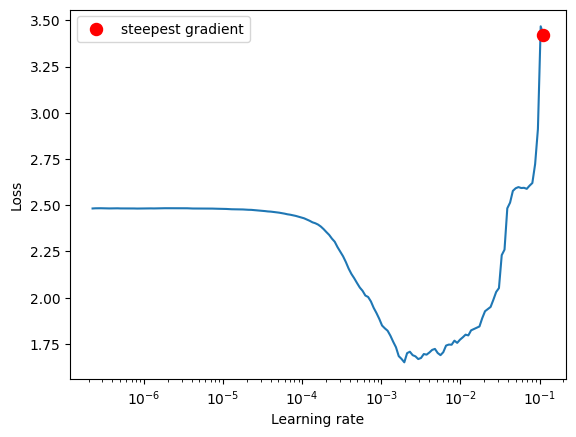

🔍 Class Weights Tensor:
tensor([2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832, 2.4832,
        2.4832, 2.4832, 2.4832], device='cuda:0')
🔍 Shape of one stream sample: torch.Size([32, 1, 51])


/home/ea301b/anaconda3/envs/dl_satang/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/70 - Train Loss: 190.5691 - Val Loss: 14.9695 - Train Acc: 0.7048 - Val Acc: 0.7380
Epoch 2/70 - Train Loss: 112.2994 - Val Loss: 15.6157 - Train Acc: 0.8214 - Val Acc: 0.7336
Epoch 3/70 - Train Loss: 91.4783 - Val Loss: 9.8915 - Train Acc: 0.8549 - Val Acc: 0.8443
Epoch 4/70 - Train Loss: 74.5855 - Val Loss: 12.1567 - Train Acc: 0.8841 - Val Acc: 0.7977
Epoch 5/70 - Train Loss: 70.4364 - Val Loss: 11.7510 - Train Acc: 0.8911 - Val Acc: 0.8006
Epoch 6/70 - Train Loss: 67.9938 - Val Loss: 11.5290 - Train Acc: 0.8976 - Val Acc: 0.8239
Epoch 7/70 - Train Loss: 60.1983 - Val Loss: 8.7314 - Train Acc: 0.9121 - Val Acc: 0.8705
Epoch 8/70 - Train Loss: 49.4747 - Val Loss: 6.9896 - Train Acc: 0.9214 - Val Acc: 0.8937
Epoch 9/70 - Train Loss: 48.3778 - Val Loss: 7.8743 - Train Acc: 0.9272 - Val Acc: 0.8719
Epoch 10/70 - Train Loss: 42.3776 - Val Loss: 12.7526 - Train Acc: 0.9373 - Val Acc: 0.8297
Epoch 11/70 - Train Loss: 43.8098 - Val Loss: 7.5585 - Train Acc: 0.9361 - Val Acc: 0.8865


/tmp/ipykernel_468431/1221068975.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


✅ Final teacher model saved as 'teacher_smote_train_only.pth'


In [17]:
from torch_lr_finder import LRFinder
NUM_EPOCHS = 70 
# === 🔁 LEARNING RATE FINDER ===
print("\n=== 🧠 Retraining Teacher Model ===")
model_for_lr = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_)).to(device)

# ✅ Use AdamW + weight decay during LR finding (important for stability!)
optimizer = torch.optim.AdamW(model_for_lr.parameters(), lr=1e-7, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print("🔍 Finding optimal learning rate...")
lr_finder = LRFinder(model_for_lr, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=1, num_iter=200)
lr_finder.plot()
lr_finder.reset()

# === Use best LR after checking the LR plot
BEST_LR = 0.001  # Replace this based on your LR curve

# === Train Teacher
# === Train Teacher ===
final_teacher = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_)).to(device)

# ✅ AdamW with regularization
optimizer = torch.optim.AdamW(final_teacher.parameters(), lr=BEST_LR, weight_decay=1e-4)

# ✅ CosineAnnealingLR for smooth convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# ✅ If train_model supports custom optimizer/scheduler
train_accs, val_accs, train_losses, val_losses = train_model(
    model=final_teacher,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=NUM_EPOCHS,
    class_weights=class_weights_tensor,
    lr=BEST_LR,
    optimizer=optimizer,
    scheduler=scheduler
)

# === Save model
torch.save(final_teacher.state_dict(), "teacher_smote_train_only.pth")
print("✅ Final teacher model saved as 'teacher_smote_train_only.pth'")

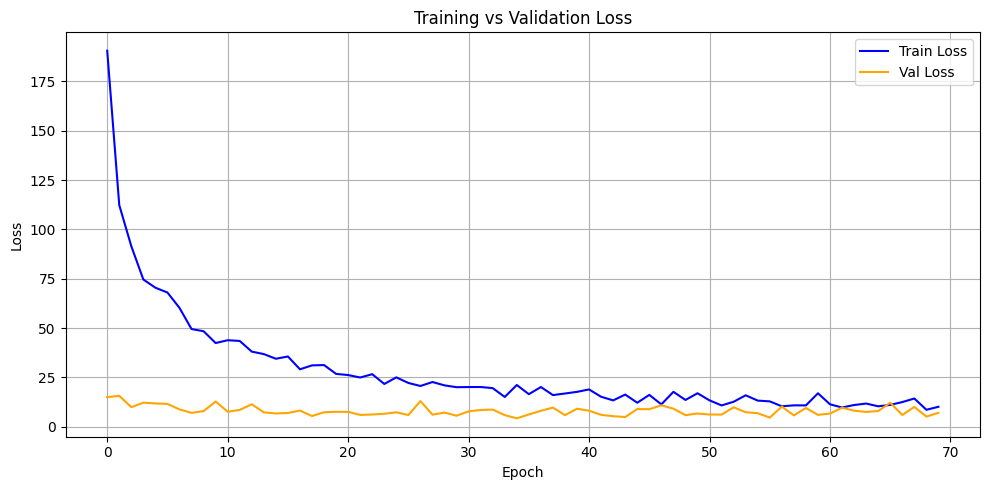

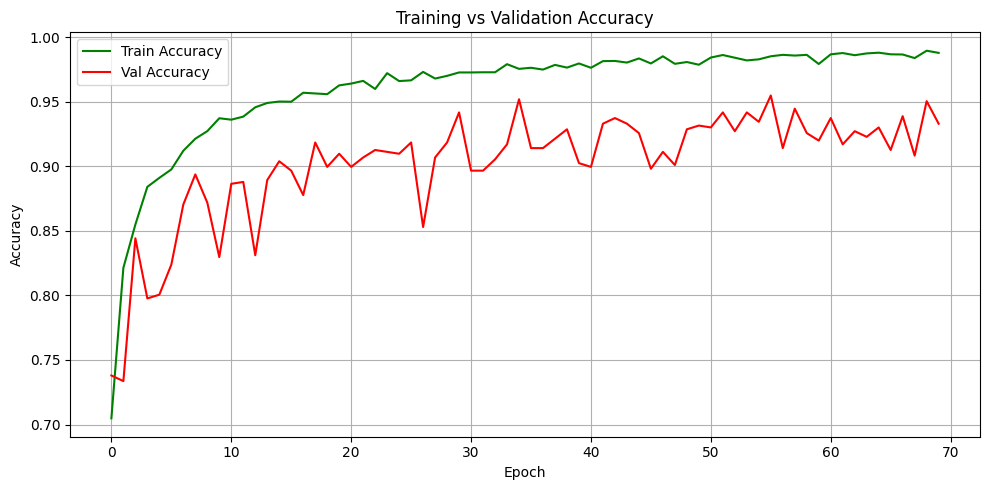

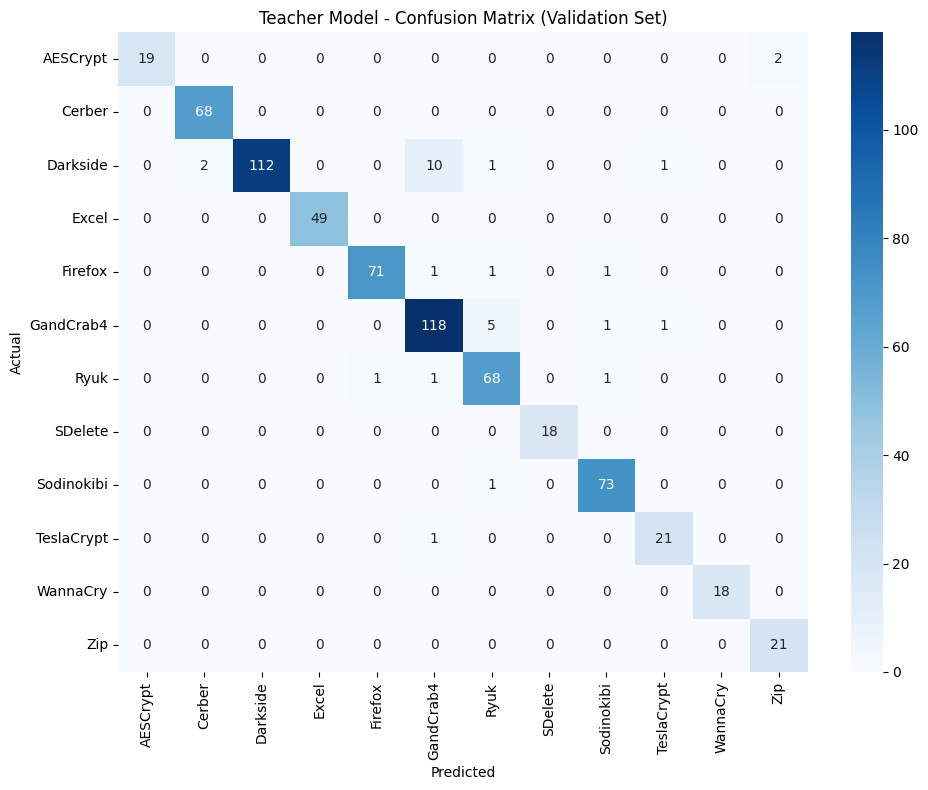


Final Classification Report (Teacher):

              precision    recall  f1-score   support

    AESCrypt       1.00      0.90      0.95        21
      Cerber       0.97      1.00      0.99        68
    Darkside       1.00      0.89      0.94       126
       Excel       1.00      1.00      1.00        49
     Firefox       0.99      0.96      0.97        74
   GandCrab4       0.90      0.94      0.92       125
        Ryuk       0.89      0.96      0.93        71
     SDelete       1.00      1.00      1.00        18
  Sodinokibi       0.96      0.99      0.97        74
  TeslaCrypt       0.91      0.95      0.93        22
    WannaCry       1.00      1.00      1.00        18
         Zip       0.91      1.00      0.95        21

    accuracy                           0.95       687
   macro avg       0.96      0.97      0.96       687
weighted avg       0.96      0.95      0.95       687


Final Training Accuracy: 0.9879
Final Validation Accuracy: 0.9330


In [18]:
# === 🔍 Plot training curves
plot_loss_curve(train_losses, val_losses)
plot_accuracy_curve(train_accs, val_accs)

# === 📊 Evaluate on validation set (same used during training)
final_teacher.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = final_teacher(streams)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Confusion Matrix & Report
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Teacher Model - Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Classification Report (Teacher):\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))

print(f"\nFinal Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")

🧠 Multi-class AUC (macro): 0.9981


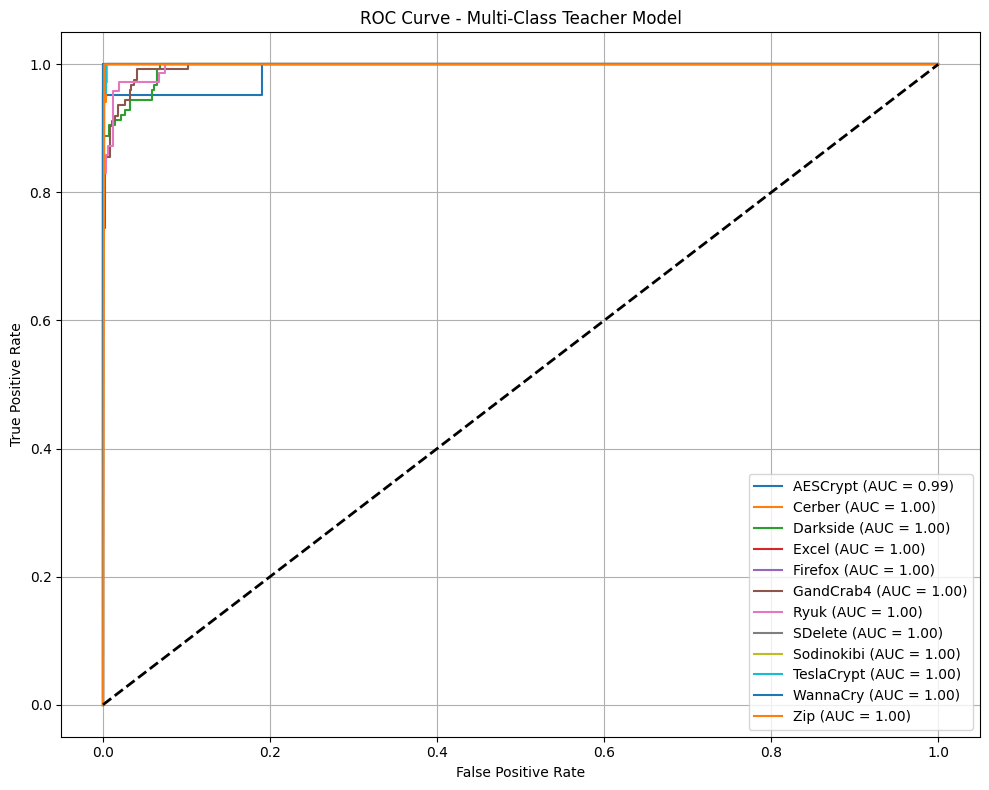

In [19]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# === 1. Get predictions on validation set ===
final_teacher.eval()
y_true = []
y_probs = []

with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.cpu().numpy()
        outputs = final_teacher(streams)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        
        y_probs.extend(probs)
        y_true.extend(labels)

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# === 2. Binarize labels for ROC AUC ===
y_true_bin = label_binarize(y_true, classes=range(len(label_encoder.classes_)))

# === 3. Compute AUC score (macro-average) ===
auc_macro = roc_auc_score(y_true_bin, y_probs, average="macro", multi_class="ovr")
print(f"🧠 Multi-class AUC (macro): {auc_macro:.4f}")

# === 4. Plot ROC curves per class ===
plt.figure(figsize=(10, 8))
for i in range(len(label_encoder.classes_)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class Teacher Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
import torch
import torch.nn as nn
import time
import os
import psutil
import copy
from thop import profile

# === Profiling functions ===
def get_stream_macs_params(stream, input_length):
    dummy_input = torch.randn(1, 1, input_length)
    stream_copy = copy.deepcopy(stream)
    macs, params = profile(stream_copy, inputs=(dummy_input,), verbose=False)
    return macs, params

def get_linear_macs_params(layer, in_features):
    dummy_input = torch.randn(1, in_features)
    layer_copy = copy.deepcopy(layer)
    macs, params = profile(layer_copy, inputs=(dummy_input,), verbose=False)
    return macs, params

# === Utility functions ===
def get_model_size(model):
    temp_path = "temp_model.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 ** 2)
    os.remove(temp_path)
    return size_mb

def measure_latency(model, inputs, n_runs=100):
    model.eval()
    with torch.no_grad():
        start = time.time()
        for _ in range(n_runs):
            model(inputs)
        end = time.time()
    return (end - start) / n_runs * 1000

def measure_cpu_usage(model, inputs, duration=2):
    model.eval()
    process = psutil.Process(os.getpid())
    num_cpus = psutil.cpu_count(logical=True)
    _ = process.cpu_percent(interval=None)
    with torch.no_grad():
        start_time = time.time()
        while time.time() - start_time < duration:
            model(inputs)
    total_cpu_percent = process.cpu_percent(interval=None)
    return total_cpu_percent / num_cpus

# === Main Evaluation ===
def evaluate_full_model(model_class, model_path, input_length, stream_count=5, *args, **kwargs):
    # Create two clean models (one for profiling, one for latency)
    prof_model = model_class(input_length=input_length, *args, **kwargs)
    prof_model.load_state_dict(torch.load(model_path))
    prof_model.eval()

    clean_model = model_class(input_length=input_length, *args, **kwargs)
    clean_model.load_state_dict(torch.load(model_path))
    clean_model.eval()

    total_macs, total_params = 0, 0

    print("🔍 Stream MAC breakdown:")
    for i in range(stream_count):
        macs_i, params_i = get_stream_macs_params(prof_model.streams[i], input_length)
        print(f"  Stream[{i}] MACs: {macs_i}, Params: {params_i}")
        total_macs += macs_i
        total_params += params_i

    print("\n🔍 FC Layer breakdown:")
    fc0, fc3, fc6, fc8 = prof_model.fc[1], prof_model.fc[4], prof_model.fc[7], prof_model.fc[8]
    macs_fc0, params_fc0 = get_linear_macs_params(fc0, in_features=256 * stream_count)
    macs_fc3, params_fc3 = get_linear_macs_params(fc3, in_features=512)
    macs_fc6, params_fc6 = get_linear_macs_params(fc6, in_features=256)
    macs_fc8, params_fc8 = get_linear_macs_params(fc8, in_features=128)
    total_macs += macs_fc0 + macs_fc3 + macs_fc6 + macs_fc8
    total_params += params_fc0 + params_fc3 + params_fc6 + params_fc8
    print(f"  FC[0] (1280→512): {macs_fc0}, Params: {params_fc0}")
    print(f"  FC[3] (512→256): {macs_fc3}, Params: {params_fc3}")
    print(f"  FC[6] (256→128): {macs_fc6}, Params: {params_fc6}")
    print(f"  FC[8] (128→classes): {macs_fc8}, Params: {params_fc8}")

    print("\n🔍 Projection Layer:")
    macs_proj, params_proj = get_linear_macs_params(prof_model.proj, in_features=256 * stream_count)
    total_macs += macs_proj
    total_params += params_proj
    print(f"  Proj (1280→128): {macs_proj}, Params: {params_proj}")

    flops = 2 * total_macs
    size_mb = get_model_size(clean_model)
    dummy_inputs = [torch.randn(1, 1, input_length) for _ in range(stream_count)]
    latency = measure_latency(clean_model, dummy_inputs)
    cpu_usage = measure_cpu_usage(clean_model, dummy_inputs)

    return {
        "Model Size (MB)": round(size_mb, 4),
        "Latency (ms)": round(latency, 3),
        "CPU Usage (%)": round(cpu_usage, 2),
        "Total MACs": int(total_macs),
        "FLOPs": int(flops),
        "Total Params": int(total_params)
    }

# === Usage ===
# You must define your StudentCNN class and load the model first
model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("teacher_full.pth"))
# Then:
#torch.save(model.state_dict(), "student_model.pth")
stats = evaluate_full_model(
    MultiStreamCNN,
    "teacher_full.pth",
    input_length=CHUNK_SIZE,
    num_classes=12
)
for k, v in stats.items():
    print(f"{k}: {v}")


/tmp/ipykernel_468431/983760966.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("teacher_full.pth"))
/tmp/ipykernel_468431/983760966.p

🔍 Stream MAC breakdown:
  Stream[0] MACs: 23608448.0, Params: 831392.0
  Stream[1] MACs: 23608448.0, Params: 831392.0
  Stream[2] MACs: 23608448.0, Params: 831392.0
  Stream[3] MACs: 23608448.0, Params: 831392.0
  Stream[4] MACs: 23608448.0, Params: 831392.0

🔍 FC Layer breakdown:
  FC[0] (1280→512): 655360.0, Params: 0
  FC[3] (512→256): 131072.0, Params: 0
  FC[6] (256→128): 32768.0, Params: 0
  FC[8] (128→classes): 0.0, Params: 0

🔍 Projection Layer:
  Proj (1280→128): 163840.0, Params: 0
Model Size (MB): 19.8065
Latency (ms): 37.001
CPU Usage (%): 49.5
Total MACs: 119025280
FLOPs: 238050560
Total Params: 4156960


/tmp/ipykernel_468431/3475220102.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("teacher_full.pth"))


=== 🧪 Final Test Set Classification Report ===
              precision    recall  f1-score   support

    AESCrypt     1.0000    1.0000    1.0000        22
      Cerber     1.0000    0.9851    0.9925        67
    Darkside     0.9762    0.9609    0.9685       128
       Excel     0.9701    1.0000    0.9848        65
     Firefox     0.9474    1.0000    0.9730        72
   GandCrab4     0.9440    0.9365    0.9402       126
        Ryuk     0.9155    0.8904    0.9028        73
     SDelete     1.0000    1.0000    1.0000        21
  Sodinokibi     0.9859    0.9459    0.9655        74
  TeslaCrypt     0.9143    1.0000    0.9552        32
    WannaCry     1.0000    1.0000    1.0000        26
         Zip     1.0000    1.0000    1.0000        22

    accuracy                         0.9643       728
   macro avg     0.9711    0.9766    0.9735       728
weighted avg     0.9646    0.9643    0.9642       728



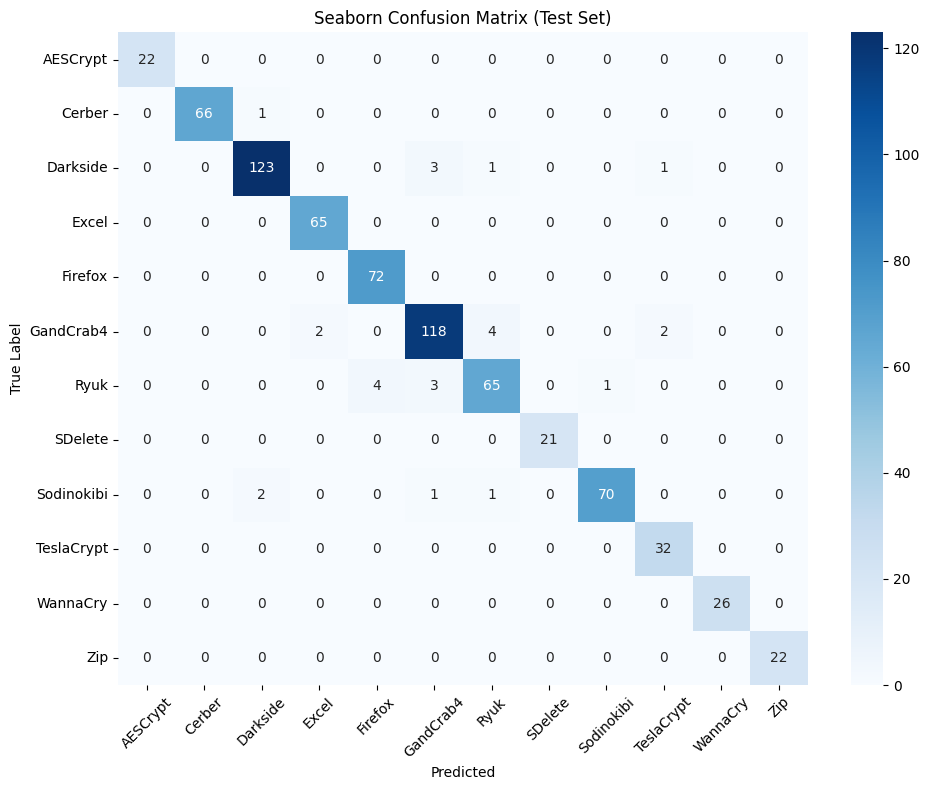

In [21]:
expected_shape = (CHUNK_SIZE, NUM_FEATURES)
X_test, y_test = load_split_from_folder(os.path.join(INPUT_DIR, "test"), expected_shape)
y_test_str = y_test

test_dataset = MultiStreamDataset(X_test, y_test_str, label_encoder, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Rebuild same model architecture
model = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("teacher_full.pth"))
model.to(device)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for streams, labels in test_loader:
        # Move to device
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)

        outputs = model(streams)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Inverse-transform for reporting
pred_labels_str = label_encoder.inverse_transform(all_preds)
true_labels_str = label_encoder.inverse_transform(all_labels)

# === 5. Classification Report
print("=== 🧪 Final Test Set Classification Report ===")
print(classification_report(true_labels_str, pred_labels_str, digits=4))

# === 6. Seaborn Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Seaborn Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:
import torch
import torch.nn as nn

class StudentCNN(nn.Module):
    def __init__(self, input_length, num_classes=12):
        super().__init__()
        self.streams = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(1, 4, kernel_size=3, padding=1),  # reduced filters
                nn.ReLU(),
                nn.Conv1d(4, 8, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten()
            ) for _ in range(5)
        ])

        self.fc = nn.Sequential(
            nn.Linear(8 * 5, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

        # 🔄 Smaller projection for lightweight feature distillation
        self.proj = nn.Linear(8 * 5, 128)

    def forward(self, streams, return_features=False):
        features = [self.streams[i](streams[i]) for i in range(5)]
        x = torch.cat(features, dim=1)  # Shape: [B, 64]

        if return_features:
            feat_proj = self.proj(x)  # [B, 128]
            return self.fc(x), feat_proj

        return self.fc(x)


In [23]:
import torch.nn.functional as F

def distillation_loss(student_logits, teacher_logits, student_feat, teacher_feat, true_labels, T=3.0, alpha=0.5, beta=0.3, gamma=0.2):
    """
    alpha: weight for hard loss (CE)
    beta: weight for soft loss (KL)
    gamma: weight for feature-based distillation (MSE)
    T: temperature for soft distillation
    """
    # Hard loss
    ce_loss = F.cross_entropy(student_logits, true_labels)

    # Soft loss (logits)
    soft_teacher = F.softmax(teacher_logits / T, dim=1)
    soft_student = F.log_softmax(student_logits / T, dim=1)
    kl_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (T * T)

    # Feature loss (projection-matched MSE)
    feat_loss = F.mse_loss(student_feat, teacher_feat)

    return alpha * ce_loss + beta * kl_loss + gamma * feat_loss


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

def train_distilled(student, teacher, train_loader, val_loader, device,
                    epochs=50, lr=0.0005, class_weights=None,
                    T=3.0, alpha=0.3, gamma=0.1,
                    save_path="best_student.pth"):

    teacher.eval()
    student.to(device)
    teacher.to(device)

    optimizer = optim.Adam(student.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_acc = 0
    train_losses, train_accuracies, val_accuracies, val_losses = [], [], [], []

    for epoch in range(epochs):
        student.train()
        total_loss = 0
        correct = 0

        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            # Forward pass with feature distillation
            student_logits, student_feat = student(streams, return_features=True)
            with torch.no_grad():
                teacher_logits, teacher_feat = teacher(streams, return_features=True)

            loss = distillation_loss(
                student_logits, teacher_logits,
                student_feat, teacher_feat,
                labels,
                T=3.0, alpha=0.5, beta=0.3, gamma=0.2
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (student_logits.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        student.eval()
        val_correct = 0
        val_loss = 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)

                outputs = student(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)

        print(f"[Distill] Epoch {epoch+1:02d}/{epochs} - Loss: {total_loss:.4f} "
              f"- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        # Save best model checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student.state_dict(), save_path)

    # Load the best model after full training
    student.load_state_dict(torch.load(save_path))
    return train_accuracies, val_accuracies, train_losses, val_losses


/tmp/ipykernel_468431/3006048006.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher.load_state_dict(torch.load("teacher_full.pth", map_location=device))


🔍 Finding optimal learning rate...


100%|██████████| 200/200 [00:02<00:00, 68.44it/s]


Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 7.49E-02


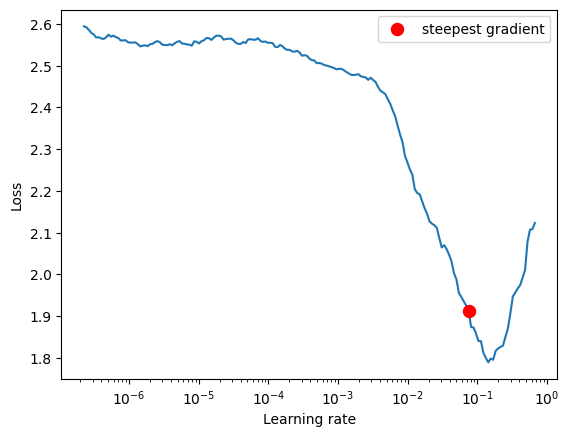

[Distill] Epoch 01/70 - Loss: 987.1328 - Train Acc: 0.4955 - Val Acc: 0.6172
[Distill] Epoch 02/70 - Loss: 478.9960 - Train Acc: 0.7460 - Val Acc: 0.6769
[Distill] Epoch 03/70 - Loss: 325.8411 - Train Acc: 0.8235 - Val Acc: 0.7569
[Distill] Epoch 04/70 - Loss: 265.6528 - Train Acc: 0.8549 - Val Acc: 0.7758
[Distill] Epoch 05/70 - Loss: 230.2945 - Train Acc: 0.8738 - Val Acc: 0.8151
[Distill] Epoch 06/70 - Loss: 208.5671 - Train Acc: 0.8872 - Val Acc: 0.8443
[Distill] Epoch 07/70 - Loss: 198.3506 - Train Acc: 0.8902 - Val Acc: 0.8311
[Distill] Epoch 08/70 - Loss: 179.5202 - Train Acc: 0.9032 - Val Acc: 0.8574
[Distill] Epoch 09/70 - Loss: 161.6527 - Train Acc: 0.9083 - Val Acc: 0.8355
[Distill] Epoch 10/70 - Loss: 171.6816 - Train Acc: 0.9025 - Val Acc: 0.8297
[Distill] Epoch 11/70 - Loss: 159.9628 - Train Acc: 0.9135 - Val Acc: 0.8311
[Distill] Epoch 12/70 - Loss: 158.2517 - Train Acc: 0.9164 - Val Acc: 0.8501
[Distill] Epoch 13/70 - Loss: 148.3074 - Train Acc: 0.9175 - Val Acc: 0.8705

/tmp/ipykernel_468431/3063980865.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(save_path))


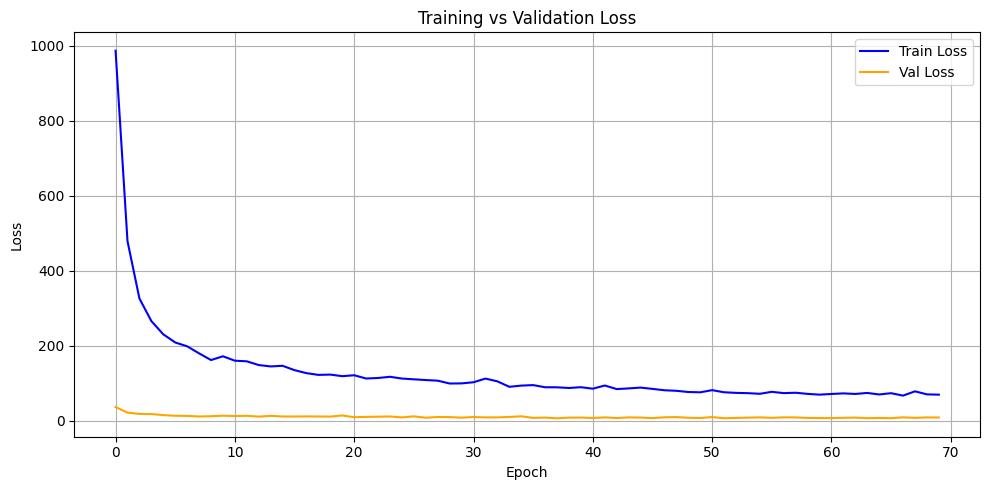

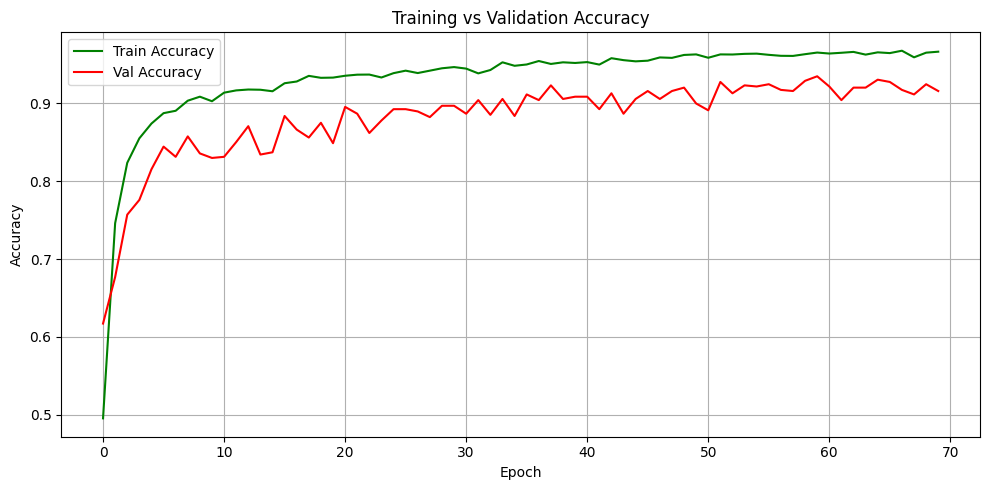

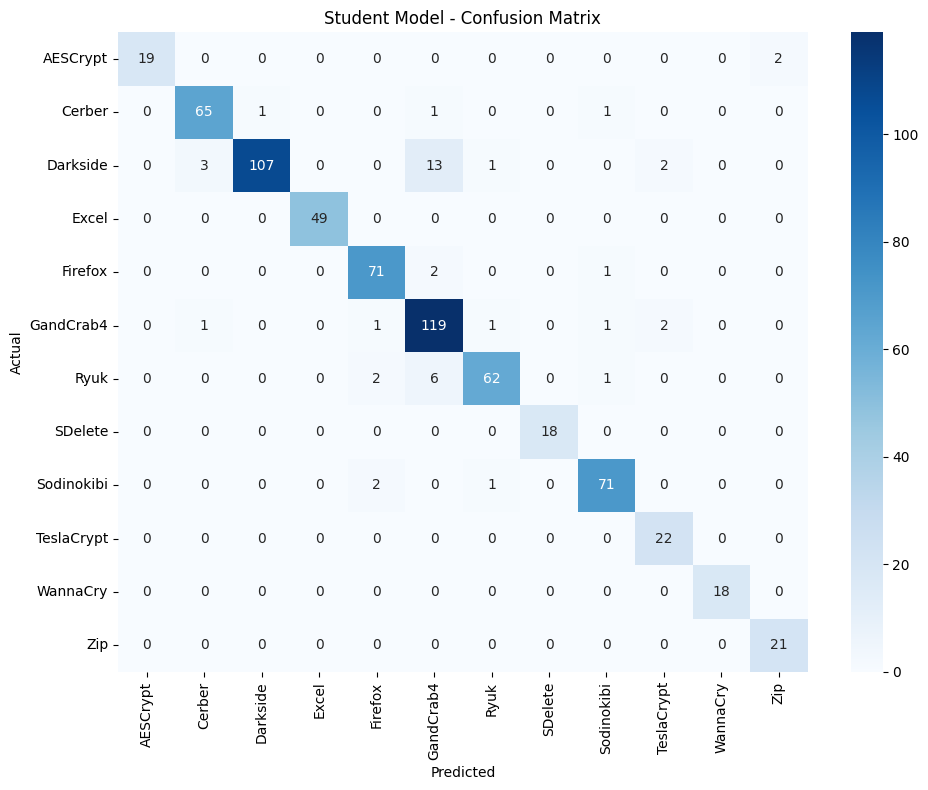


Final Classification Report (Student):

              precision    recall  f1-score   support

    AESCrypt       1.00      0.90      0.95        21
      Cerber       0.94      0.96      0.95        68
    Darkside       0.99      0.85      0.91       126
       Excel       1.00      1.00      1.00        49
     Firefox       0.93      0.96      0.95        74
   GandCrab4       0.84      0.95      0.89       125
        Ryuk       0.95      0.87      0.91        71
     SDelete       1.00      1.00      1.00        18
  Sodinokibi       0.95      0.96      0.95        74
  TeslaCrypt       0.85      1.00      0.92        22
    WannaCry       1.00      1.00      1.00        18
         Zip       0.91      1.00      0.95        21

    accuracy                           0.93       687
   macro avg       0.95      0.95      0.95       687
weighted avg       0.94      0.93      0.93       687


Final Training Accuracy: 0.9661
Final Validation Accuracy: 0.9156


In [25]:
# === Load frozen teacher
teacher = MultiStreamCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
teacher.load_state_dict(torch.load("teacher_full.pth", map_location=device))
teacher.to(device)
teacher.eval()


model_for_lr = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_)).to(device)
optimizer = torch.optim.Adam(model_for_lr.parameters(), lr=1e-7)  # Fresh model + optimizer

print("🔍 Finding optimal learning rate...")
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
lr_finder = LRFinder(model_for_lr, optimizer, criterion, device=device)
lr_finder.range_test(train_loader, end_lr=1, num_iter=200)
lr_finder.plot()
lr_finder.reset()

# === Use best LR after checking the LR plot
BEST_LR = 0.005  # Replace this based on your LR curve

# === Train student with KD
student = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
train_accs, val_accs, train_losses, val_losses = train_distilled(
    student, teacher, train_loader, val_loader, device,
    epochs=NUM_EPOCHS, lr=BEST_LR, class_weights=class_weights_tensor,
    T=3.0, alpha=0.5
)

# === Plot
plot_loss_curve(train_losses, val_losses)
plot_accuracy_curve(train_accs, val_accs)

# === Evaluate
student.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = student(streams)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# === Report
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Student Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nFinal Classification Report (Student):\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))
print(f"\nFinal Training Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_student_baseline(student, train_loader, val_loader, device,
                           epochs=50, lr=0.0005, class_weights=None, save_path="best_student_baseline.pth"):

    student.to(device)
    optimizer = optim.Adam(student.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_acc = 0
    train_losses, train_accuracies, val_accuracies, val_losses = [], [], [], []

    for epoch in range(epochs):
        student.train()
        total_loss = 0
        correct = 0

        for streams, labels in train_loader:
            streams = [s.to(device) for s in streams]
            labels = labels.to(device)

            outputs = student(streams)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_loader.dataset)
        train_losses.append(total_loss)
        train_accuracies.append(train_acc)

        # === Validation ===
        student.eval()
        val_correct = 0
        val_loss = 0
        with torch.no_grad():
            for streams, labels in val_loader:
                streams = [s.to(device) for s in streams]
                labels = labels.to(device)

                outputs = student(streams)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_loader.dataset)
        val_accuracies.append(val_acc)
        val_losses.append(val_loss)

        print(f"[Baseline] Epoch {epoch+1:02d}/{epochs} - Loss: {total_loss:.4f} "
              f"- Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        # ✅ Save best model checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(student.state_dict(), save_path)

    # ✅ Load the best saved model after full training
    student.load_state_dict(torch.load(save_path))
    return train_accuracies, val_accuracies, train_losses, val_losses


In [27]:
# === BASELINE STUDENT TRAINING (No KD) ===

student_baseline = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))

train_accs_b, val_accs_b, train_losses_b, val_losses_b = train_student_baseline(
    student_baseline, train_loader, val_loader, device,
    epochs=NUM_EPOCHS, lr=0.001, class_weights=class_weights_tensor
)
# === Save model
# torch.save(student_baseline.state_dict(), "student_baseline.pth")
print("✅ saved as student_baseline.pth'")

[Baseline] Epoch 01/70 - Loss: 383.2810 - Train Acc: 0.4018 - Val Acc: 0.5109
[Baseline] Epoch 02/70 - Loss: 210.2409 - Train Acc: 0.6758 - Val Acc: 0.6186
[Baseline] Epoch 03/70 - Loss: 155.3105 - Train Acc: 0.7677 - Val Acc: 0.6696
[Baseline] Epoch 04/70 - Loss: 128.6315 - Train Acc: 0.8063 - Val Acc: 0.7060
[Baseline] Epoch 05/70 - Loss: 111.2675 - Train Acc: 0.8325 - Val Acc: 0.7467
[Baseline] Epoch 06/70 - Loss: 95.7189 - Train Acc: 0.8592 - Val Acc: 0.7787
[Baseline] Epoch 07/70 - Loss: 87.6192 - Train Acc: 0.8664 - Val Acc: 0.8093
[Baseline] Epoch 08/70 - Loss: 80.6443 - Train Acc: 0.8765 - Val Acc: 0.7773
[Baseline] Epoch 09/70 - Loss: 73.7430 - Train Acc: 0.8879 - Val Acc: 0.8079
[Baseline] Epoch 10/70 - Loss: 67.3807 - Train Acc: 0.8940 - Val Acc: 0.8151
[Baseline] Epoch 11/70 - Loss: 63.3945 - Train Acc: 0.9036 - Val Acc: 0.8617
[Baseline] Epoch 12/70 - Loss: 61.4505 - Train Acc: 0.9044 - Val Acc: 0.8370
[Baseline] Epoch 13/70 - Loss: 56.8693 - Train Acc: 0.9132 - Val Acc: 0

/tmp/ipykernel_468431/1403345829.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  student.load_state_dict(torch.load(save_path))


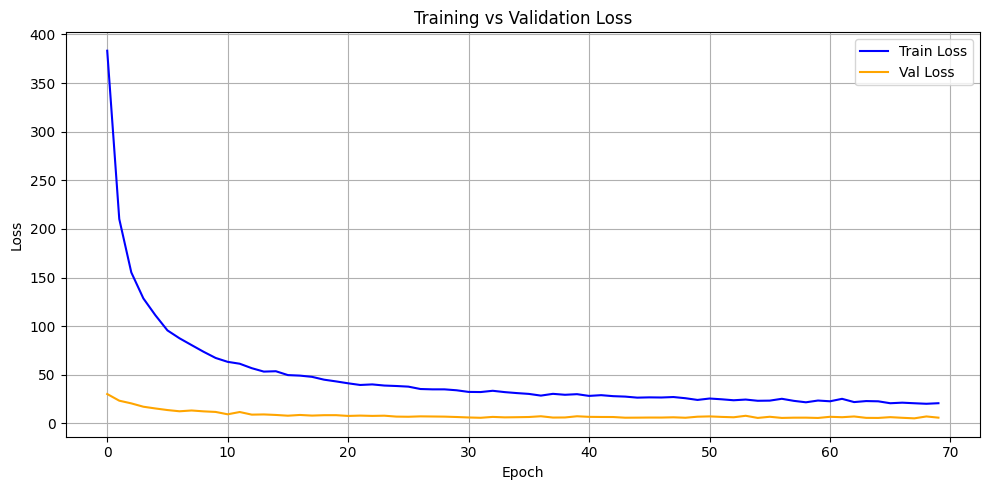

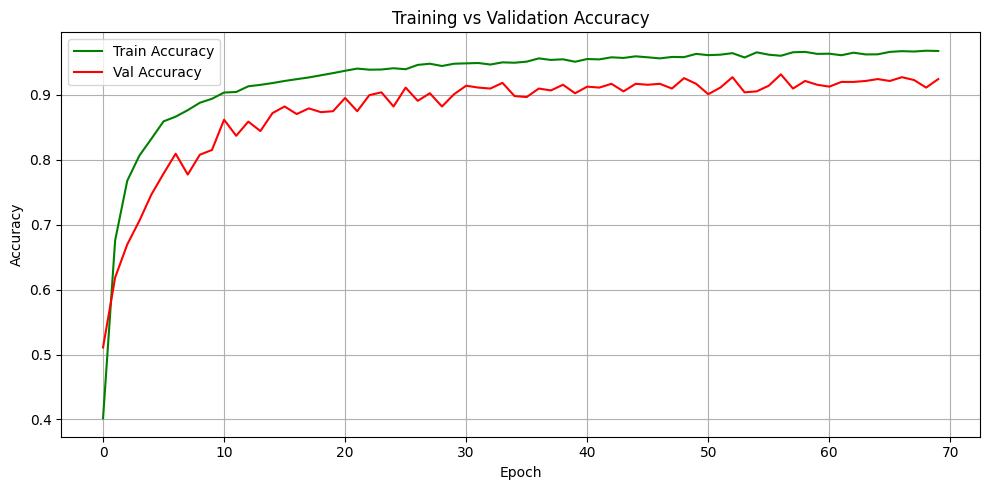

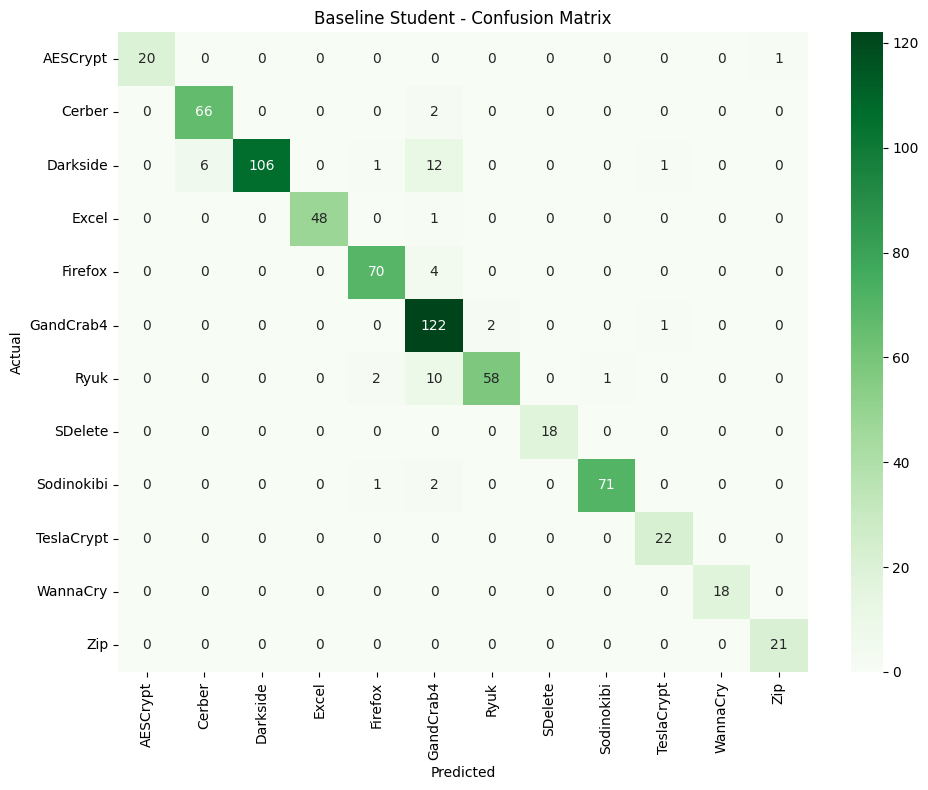


📋 Baseline Classification Report (Student, No KD):

              precision    recall  f1-score   support

    AESCrypt       1.00      0.95      0.98        21
      Cerber       0.92      0.97      0.94        68
    Darkside       1.00      0.84      0.91       126
       Excel       1.00      0.98      0.99        49
     Firefox       0.95      0.95      0.95        74
   GandCrab4       0.80      0.98      0.88       125
        Ryuk       0.97      0.82      0.89        71
     SDelete       1.00      1.00      1.00        18
  Sodinokibi       0.99      0.96      0.97        74
  TeslaCrypt       0.92      1.00      0.96        22
    WannaCry       1.00      1.00      1.00        18
         Zip       0.95      1.00      0.98        21

    accuracy                           0.93       687
   macro avg       0.96      0.95      0.95       687
weighted avg       0.94      0.93      0.93       687

✅ Final Training Accuracy (baseline): 0.9676
✅ Final Validation Accuracy (baseli

In [28]:
student_baseline.eval()
final_preds_b, final_labels_b = [], []
with torch.no_grad():
    for streams, labels in val_loader:
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)
        outputs = student_baseline(streams)
        preds = torch.argmax(outputs, dim=1)
        final_preds_b.extend(preds.cpu().numpy())
        final_labels_b.extend(labels.cpu().numpy())
# === Plot
plot_loss_curve(train_losses_b, val_losses_b)
plot_accuracy_curve(train_accs_b, val_accs_b)
# Confusion matrix
cm_b = confusion_matrix(final_labels_b, final_preds_b)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Baseline Student - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Report
print("\n📋 Baseline Classification Report (Student, No KD):\n")
print(classification_report(final_labels_b, final_preds_b, target_names=label_encoder.classes_))
print(f"✅ Final Training Accuracy (baseline): {train_accs_b[-1]:.4f}")
print(f"✅ Final Validation Accuracy (baseline): {val_accs_b[-1]:.4f}")


In [29]:
expected_shape = (CHUNK_SIZE, NUM_FEATURES)
X_test, y_test = load_split_from_folder(os.path.join(INPUT_DIR, "test"), expected_shape)
y_test_str = y_test

test_dataset = MultiStreamDataset(X_test, y_test_str, label_encoder, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)


/tmp/ipykernel_468431/952631451.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_student_baseline.pth"))


=== 🧪 Final Test Set Classification Report ===
              precision    recall  f1-score   support

    AESCrypt     1.0000    1.0000    1.0000        22
      Cerber     0.9296    0.9851    0.9565        67
    Darkside     0.9835    0.9297    0.9558       128
       Excel     0.9403    0.9692    0.9545        65
     Firefox     0.9726    0.9861    0.9793        72
   GandCrab4     0.8120    0.8571    0.8340       126
        Ryuk     0.8194    0.8082    0.8138        73
     SDelete     1.0000    1.0000    1.0000        21
  Sodinokibi     0.9552    0.8649    0.9078        74
  TeslaCrypt     0.9118    0.9688    0.9394        32
    WannaCry     1.0000    0.9615    0.9804        26
         Zip     1.0000    1.0000    1.0000        22

    accuracy                         0.9217       728
   macro avg     0.9437    0.9442    0.9435       728
weighted avg     0.9235    0.9217    0.9220       728



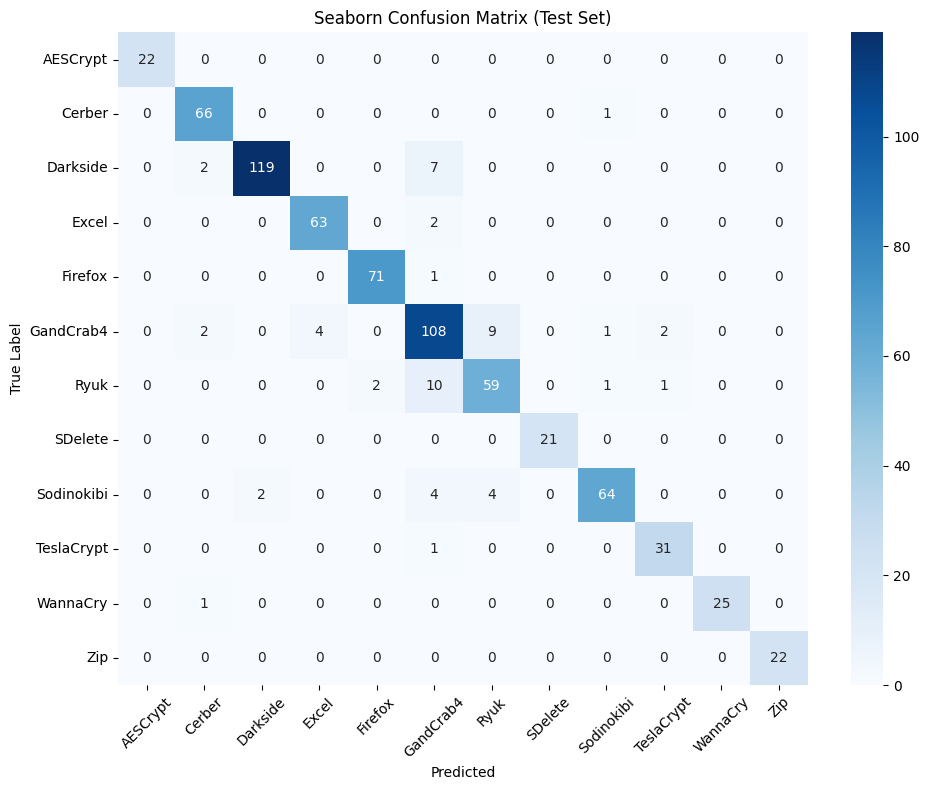

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Rebuild same model architecture
model = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("best_student_baseline.pth"))
model.to(device)
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for streams, labels in test_loader:
        # Move to device
        streams = [s.to(device) for s in streams]
        labels = labels.to(device)

        outputs = model(streams)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Inverse-transform for reporting
pred_labels_str = label_encoder.inverse_transform(all_preds)
true_labels_str = label_encoder.inverse_transform(all_labels)

# === 5. Classification Report
print("=== 🧪 Final Test Set Classification Report ===")
print(classification_report(true_labels_str, pred_labels_str, digits=4))

# === 6. Seaborn Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels_str, labels=label_encoder.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.title("Seaborn Confusion Matrix (Test Set)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
import torch
import torch.nn as nn
import time
import os
import psutil
import copy
from thop import profile

# === Profiling functions ===
def get_stream_macs_params(stream, input_length):
    dummy_input = torch.randn(1, 1, input_length)
    stream_copy = copy.deepcopy(stream)
    macs, params = profile(stream_copy, inputs=(dummy_input,), verbose=False)
    return macs, params

def get_linear_macs_params(layer, in_features):
    dummy_input = torch.randn(1, in_features)
    layer_copy = copy.deepcopy(layer)
    macs, params = profile(layer_copy, inputs=(dummy_input,), verbose=False)
    return macs, params

# === Utility functions ===
def get_model_size(model):
    temp_path = "temp_model.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 ** 2)
    os.remove(temp_path)
    return size_mb

def measure_latency(model, inputs, n_runs=100):
    model.eval()
    with torch.no_grad():
        start = time.time()
        for _ in range(n_runs):
            model(inputs)
        end = time.time()
    return (end - start) / n_runs * 1000

def measure_cpu_usage(model, inputs, duration=2):
    model.eval()
    process = psutil.Process(os.getpid())
    num_cpus = psutil.cpu_count(logical=True)
    _ = process.cpu_percent(interval=None)
    with torch.no_grad():
        start_time = time.time()
        while time.time() - start_time < duration:
            model(inputs)
    total_cpu_percent = process.cpu_percent(interval=None)
    return total_cpu_percent / num_cpus

# === Main Evaluation ===
def evaluate_full_model(model_class, model_path, input_length, stream_count=5, *args, **kwargs):
    prof_model = model_class(input_length=input_length, *args, **kwargs)
    prof_model.load_state_dict(torch.load(model_path))
    prof_model.eval()

    clean_model = model_class(input_length=input_length, *args, **kwargs)
    clean_model.load_state_dict(torch.load(model_path))
    clean_model.eval()

    total_macs, total_params = 0, 0

    print("🔍 Stream MAC breakdown:")
    for i in range(stream_count):
        macs_i, params_i = get_stream_macs_params(prof_model.streams[i], input_length)
        print(f"  Stream[{i}] MACs: {macs_i}, Params: {params_i}")
        total_macs += macs_i
        total_params += params_i

    print("\n🔍 FC Layer breakdown:")
    fc0, fc4 = prof_model.fc[0], prof_model.fc[4]  # Linear(40→128), Linear(128→num_classes)
    macs_fc0, params_fc0 = get_linear_macs_params(fc0, in_features=8 * stream_count)
    macs_fc4, params_fc4 = get_linear_macs_params(fc4, in_features=128)
    total_macs += macs_fc0 + macs_fc4
    total_params += params_fc0 + params_fc4
    print(f"  FC[0] (40→128): {macs_fc0}, Params: {params_fc0}")
    print(f"  FC[4] (128→classes): {macs_fc4}, Params: {params_fc4}")

    print("\n🔍 Projection Layer:")
    macs_proj, params_proj = get_linear_macs_params(prof_model.proj, in_features=8 * stream_count)
    total_macs += macs_proj
    total_params += params_proj
    print(f"  Proj (40→128): {macs_proj}, Params: {params_proj}")

    flops = 2 * total_macs
    size_mb = get_model_size(clean_model)
    dummy_inputs = [torch.randn(1, 1, input_length) for _ in range(stream_count)]
    latency = measure_latency(clean_model, dummy_inputs)
    cpu_usage = measure_cpu_usage(clean_model, dummy_inputs)

    return {
        "Model Size (MB)": round(size_mb, 4),
        "Latency (ms)": round(latency, 3),
        "CPU Usage (%)": round(cpu_usage, 2),
        "Total MACs": int(total_macs),
        "FLOPs": int(flops),
        "Total Params": int(total_params)
    }

# === Usage ===
# You must define your StudentCNN class and load the model first
model = StudentCNN(input_length=CHUNK_SIZE, num_classes=len(label_encoder.classes_))
model.load_state_dict(torch.load("best_student_baseline.pth"))
# Then:
#torch.save(model.state_dict(), "student_model.pth")
stats = evaluate_full_model(
    StudentCNN,
    "best_student_baseline.pth",
    input_length=CHUNK_SIZE,
    num_classes=12
)
for k, v in stats.items():
    print(f"{k}: {v}")

/tmp/ipykernel_468431/1904811131.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_student_baseline.pth"))
/tmp/ipykernel_468431/1

🔍 Stream MAC breakdown:
  Stream[0] MACs: 5924.0, Params: 120.0
  Stream[1] MACs: 5924.0, Params: 120.0
  Stream[2] MACs: 5924.0, Params: 120.0
  Stream[3] MACs: 5924.0, Params: 120.0
  Stream[4] MACs: 5924.0, Params: 120.0

🔍 FC Layer breakdown:
  FC[0] (40→128): 5120.0, Params: 0
  FC[4] (128→classes): 1536.0, Params: 0

🔍 Projection Layer:
  Proj (40→128): 5120.0, Params: 0
Model Size (MB): 0.058
Latency (ms): 1.241
CPU Usage (%): 50.0
Total MACs: 41396
FLOPs: 82792
Total Params: 600


In [32]:
import shap
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ===== 1. Load model =====
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===== 2. Load data batch =====
streams, labels = next(iter(test_loader))
sample_batch = [s.to(device) for s in streams]

def batch_to_shap_input(batch):
    return torch.cat(batch, dim=1)

shap_input_full = batch_to_shap_input(sample_batch)  # [B,8,T]
shap_input_full.requires_grad = True

# ===== 3. Sample 100 examples randomly =====
torch.manual_seed(42)
np.random.seed(42)

N = shap_input_full.shape[0]
indices = np.random.choice(N, size=100)
background_idx = indices[:30]
test_idx = indices[30:]

background = shap_input_full[background_idx]
test_samples = shap_input_full[test_idx]

# ===== 4. Wrapped model (return full logits) =====
class MultiOutputWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        split = [x[:, i:i+1, :] for i in range(x.size(1))]  # List of 8 [B,1,T]
        return self.model(split)  # [B, num_classes]

wrapped_model = MultiOutputWrapper(model).to(device)
wrapped_model.eval()

# ===== 5. Run GradientExplainer for all outputs =====
explainer = shap.GradientExplainer(wrapped_model, background)
shap_values = explainer.shap_values(test_samples)  # List of [B_test, 8, T] × num_classes

# ===== 6. Global average over all classes =====
num_classes = len(shap_values)
num_streams = len(shap_values[0])  # Should be 8
avg_importance = []

for i in range(num_streams):
    stream_total = 0.0
    for c in range(num_classes):
        stream_shap = shap_values[c][:, i, :]  # [B, T]
        stream_total += np.abs(stream_shap).mean()
    avg_importance.append(stream_total / num_classes)

# ===== 7. Plot + Save Figure =====
stream_names = ["T_write", "T_read", "V_write", "V_read", "H_write", "H_var", "SLR_write", "SLR_read"]

# Sort and plot
importance_df = pd.DataFrame({'Feature': stream_names, 'Importance': avg_importance})
importance_df = importance_df.sort_values('Feature')  # Force fixed order

plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'], width=0.6)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Mean Absolute SHAP Value", fontsize=14)
plt.xlabel("Feature Stream", fontsize=14)
plt.title("Global SHAP Feature Importance Averaged Over All Classes", fontsize=16)
plt.tight_layout()

plt.savefig("global_avg_shap_per_stream.png", dpi=300)
plt.savefig("global_avg_shap_per_stream.pdf")
plt.show()

print("✅ Saved global SHAP bar plot as PNG and PDF.")


ValueError: All arrays must be of the same length

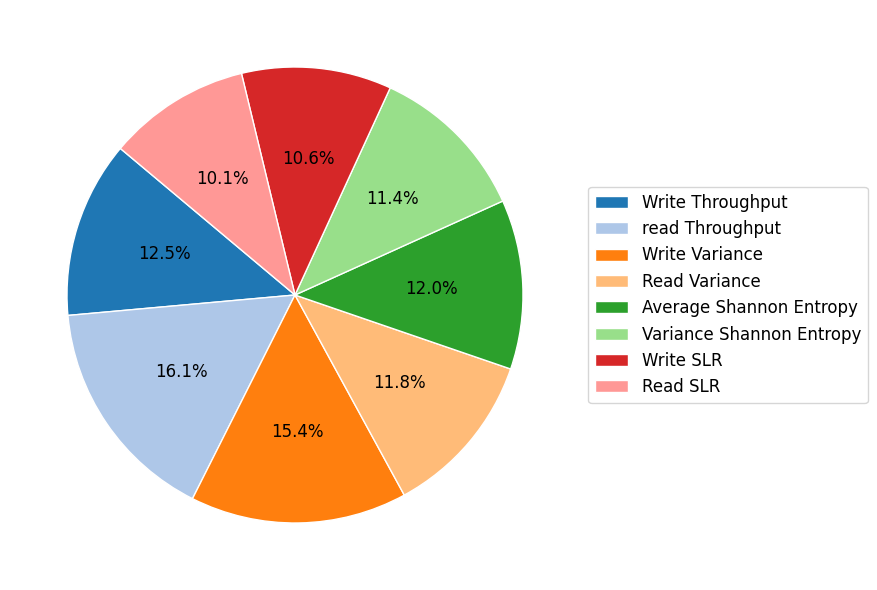

✅ Pie chart with external legend saved as PNG and PDF.


In [ ]:
import matplotlib.pyplot as plt

# ===== Pie Chart of SHAP Importance with External Legend =====
plt.figure(figsize=(10, 6))
stream_names = ["Write Throughput", "read Throughput", "Write Variance", "Read Variance", "Average Shannon Entropy", "Variance Shannon Entropy",
                 "Write SLR", "Read SLR"]

# Sort and plot
importance_df = pd.DataFrame({'Feature': stream_names, 'Importance': avg_importance})
# Keep original order based on stream_names
importance_df = pd.DataFrame({'Feature': stream_names, 'Importance': avg_importance})
colors = plt.cm.tab20.colors  # or any color palette you prefer

# Create pie chart without labels
wedges, texts, autotexts = plt.pie(
    importance_df['Importance'], 
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(importance_df)],
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white'}
)

# Add legend outside the pie
plt.legend(
    wedges, 
    importance_df['Feature'], 
    # title="Feature Streams",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title_fontsize=14
)

# plt.title('Global SHAP Feature Importance per Stream', fontsize=16)
plt.tight_layout()

# Save the plot
plt.savefig("global_avg_shap_pie_with_legend.png", dpi=300, bbox_inches="tight")
plt.savefig("global_avg_shap_pie_with_legend.pdf", bbox_inches="tight")
plt.show()

print("✅ Pie chart with external legend saved as PNG and PDF.")



shap_values_stack.shape: (12, 70, 8, 21)
shap_values_avg_time.shape: (12, 70, 8)
shap_vals_flat.shape: (70, 8)
features_flat.shape: (70, 8)


/tmp/ipykernel_1925527/1431495212.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


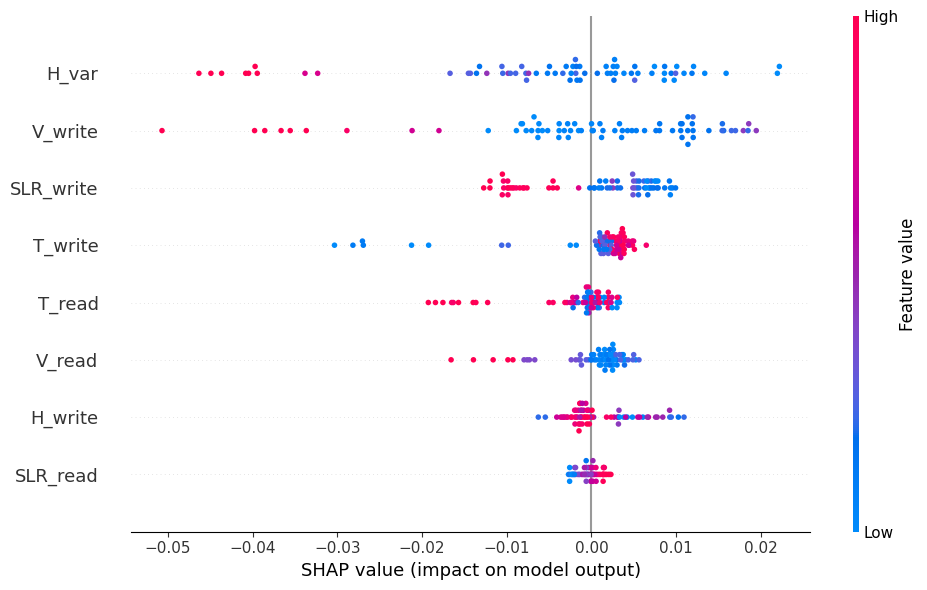

In [ ]:
# ===== 0. First fix shap_values =====
# shap_values: [70, 8, 51, 12]
shap_values_split = [shap_values[..., i] for i in range(12)]  # List of 12 arrays [70, 8, 51]

# ===== 1. Stack over classes =====
shap_values_stack = np.stack(shap_values_split, axis=0)  # [12, 70, 8, 51]
print("shap_values_stack.shape:", shap_values_stack.shape)  # Should now be (12, 70, 8, 51)

# ===== 2. Average over time (axis=3)
shap_values_avg_time = shap_values_stack.mean(axis=3)  # [12, 70, 8]
print("shap_values_avg_time.shape:", shap_values_avg_time.shape)  # (12, 70, 8)

# ===== 3. Average over classes (axis=0)
shap_vals_flat = shap_values_avg_time.mean(axis=0)  # [70, 8]
print("shap_vals_flat.shape:", shap_vals_flat.shape)  # ✅ (70, 8)

# ===== 4. Feature values (inputs)
features_flat = test_samples.detach().cpu().numpy().mean(axis=2)  # [70, 8]
print("features_flat.shape:", features_flat.shape)  # ✅ (70, 8)

# ===== 5. Plot
stream_names = ["T_write", "T_read", "V_write", "V_read", "H_write", "H_var", "SLR_write", "SLR_read"]

shap.summary_plot(
    shap_vals_flat,
    features_flat,
    feature_names=stream_names,
    plot_type="dot",
    max_display=8,
    show=False
)

plt.gcf().set_size_inches(10, 6)
plt.tight_layout()
plt.savefig("shap_beeswarm_streams.png", dpi=300, bbox_inches="tight")
plt.savefig("shap_beeswarm_streams.pdf", bbox_inches="tight")
plt.show()
